Längenmessung


In [2]:
import numpy as np
import uncertainties as unc
import uncertainties.unumpy as unp

In [3]:
err_scale = np.full(3, 0.1)

x_a = unp.uarray([98.5, 98.4, 98.5], err_scale)
x_o = unp.uarray([9.8, 9.9, 10], err_scale)
x_u = unp.uarray([7.6, 7.6, 7.55], err_scale)


In [4]:
L = x_a - 0.5*(x_o-x_u)
print(L)


sigma_stat = np.std(unp.nominal_values(L))/np.sqrt(len(L))
print(sigma_stat)

l_final = np.sqrt(sigma_stat**2 + unp.std_devs(L)**2/3)
print(l_final)

l_final/unp.nominal_values(L)

[97.4+/-0.12247448713915891 97.25+/-0.12247448713915891
 97.275+/-0.12247448713915891]
0.037883838047183906
[0.08021961 0.08021961 0.08021961]


array([0.00082361, 0.00082488, 0.00082467])

plot

Fitparameter: A0 = 18.23169±0.05405, k = 0.00020635±0.00000574


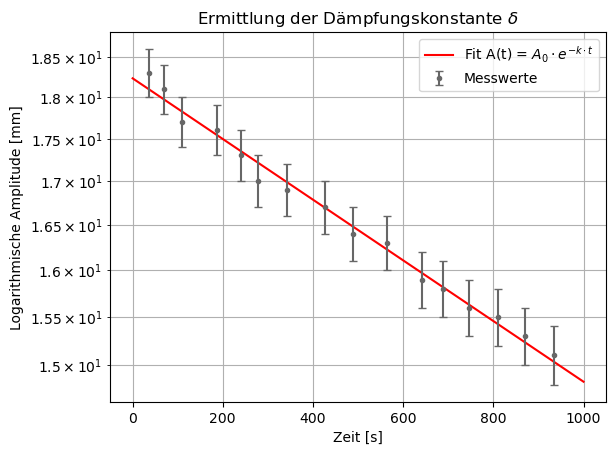

In [67]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


time = np.array([36.98, 70.1, 108.98, 186.18, 240.00, 278.99, 343.08, 426.48, 489.09, 564.50, 642.70, 687.58, 746.2, 810.4, 870.4, 933.49])

ampltude = np.array([18.30, 18.1, 17.7, 17.6, 17.3, 17.0, 16.9, 16.7, 16.4, 16.3, 15.9, 15.8, 15.6, 15.5, 15.3, 15.1]) 
err_a = 0.3

curve = lambda t, a, b: a*np.exp(-b*t)
popt, pcov = curve_fit(curve, time, ampltude, p0=(20, 0.001), sigma=err_a)

k = popt[1]

x = np.linspace(0, 1000, 100)
plt.plot(x, curve(x, *popt), '-', label=r'Fit A(t) = $A_0 \cdot e^{-k \cdot t}$', color='red')

plt.errorbar(time, ampltude, yerr=err_a, fmt='.', label=f'Messwerte', color='#676767', capsize=3)
plt.yscale('log')

plt.grid(True, which='both')
plt.xlabel('Zeit [s]')
plt.ylabel('Logarithmische Amplitude [mm]')
plt.legend()
plt.title(r'Ermittlung der Dämpfungskonstante $\delta$')


damping = unc.ufloat(k, np.sqrt(np.diag(pcov))[1])

A_0 = unc.ufloat(popt[0], np.sqrt(np.diag(pcov))[0])
print(f'Fitparameter: A0 = {A_0:.4uP}, k = {damping:.3uP}')


# Auswertung Versuch 14

Aufgabe 1

In [70]:
T = np.array([972.58, 972.53])
err_T = np.sqrt(0.21**2 + (np.std(T, ddof=1)/np.sqrt(len(T)))**2)

T = unc.ufloat(np.mean(T), err_T)
T_0 = unc.ufloat(T.n/514, T.s)


L = unc.ufloat(97.31, 0.14) * 1e-2

print(f'{T_0=:.3uP}')


T_0=1.892±0.211


In [71]:
g = 4 * np.pi**2 * L / T_0**2
g_HD = unc.ufloat(9.80984, 0.0002)

print(f'{g=:.3uP}')

(g.n - g_HD.n)/np.sqrt(g.s**2 + g_HD.s**2)

g=10.73±2.40


np.float64(0.38376422147988365)